# ADF quantification

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# Set default figuresize and font size and labelsize for plots
# plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

from glob import glob

## Simulations

In [2]:
def calculate_PAO_spectrum(e_eV):
    """
    Calculate the CR flux measured by PAO in 10 ** 17 eV < E < 10 ** 20 eV
    with the SD-750 and SD-1500.
    The formula of the spectrum is Equation (13) of
    Abreu et al., Eur. Phys. J. C 81, 966 (2021)
    (https://doi.org/10.1140/epjc/s10052-021-09700-w)
    """


    j_0 = 1.309e-18 # km^-2 yr^-1 sr^-1 eV^-1
    e_0 = 10 ** 18.5 # eV
    omega_01, omega_12, omega_23, omega_34 = 0.43, 0.05, 0.05, 0.05
    g_0, g_1, g_2, g_3, g_4 = 2.64, 3.298, 2.52, 3.08, 5.2
    e_01, e_12, e_23, e_34 = 1.24e17, 4.9e18, 1.4e19, 4.7e19 # eV

    j = j_0 * (e_eV/e_0) ** (-g_0) \
            * (1 + (e_eV/e_01) ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            * (1 + (e_eV/e_12) ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            * (1 + (e_eV/e_23) ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            * (1 + (e_eV/e_34) ** (1/omega_34)) ** ((g_3-g_4) * omega_34) \
            / (1 + (e_0/e_01)  ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            / (1 + (e_0/e_12)  ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            / (1 + (e_0/e_23)  ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            / (1 + (e_0/e_34)  ** (1/omega_34)) ** ((g_3-g_4) * omega_34)

    return j


def plot_loghist(x, bins, label, alpha, density=False,range=None):
    """
    Plot histogram in log scale
    """
    hist, bins = np.histogram(x, bins=bins, range=range)
    logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
    plt.hist(x, bins=logbins, label=label, alpha=alpha, density=density)
    plt.xscale('log')


# path_data = "/pbs/home/j/jlavoisier/pipeline_lab/ADF_quant/out_files/data_chi2_n_ant.npy"
path_sim = sorted(glob("/sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_*"))


chi2_sims = np.array([])
n_ant_trig_sims = np.array([])
theta_sims = np.array([])
phi_sims = np.array([])
theta_true = np.array([])
phi_true = np.array([])

for i in range(len(path_sim)):
    file_sims = np.load(path_sim[i])
    print("Number of simulated events in file ", path_sim[i], " : ", len(file_sims[0]))
    n_ant_trig_sims = np.append(n_ant_trig_sims, file_sims[0])
    chi2_sims = np.append(chi2_sims, file_sims[1])
    theta_sims = np.append(theta_sims, file_sims[2])
    phi_sims = np.append(phi_sims, file_sims[3])
    theta_true = np.append(theta_true, file_sims[4])
    phi_true = np.append(phi_true, file_sims[5])

print("Number of simulated events processed : ", len(chi2_sims))
print(chi2_sims)


Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0001_chi2_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0002_chi2_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0003_chi2_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0004_chi2_n_ant.npy  :  146
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0005_chi2_n_ant.npy  :  456
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0006_chi2_n_ant.npy  :  691
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/ADF_quant/out_files/batch/AN_0007_chi2_n_ant.npy  :  358
Number of simulated events in file  /sps/grand/jlavoisier/cod

In [3]:
# For energy import

path = f"/sps/grand/jlavoisier/code/quantification/check_sims/out_files/simsGP300NJ_theta_n_ant_energy.npy"

file_sims = np.load(path)

theta_tot = file_sims[0]
phi_tot = file_sims[1]
n_ant_trig_tot = file_sims[2]
energy_tot = file_sims[3]

theta = theta_tot[n_ant_trig_tot >= 5]
phi = phi_tot[n_ant_trig_tot >= 5]
energy = energy_tot[n_ant_trig_tot >= 5]

print(theta_true)

[79.37999725 80.40000153 78.26000214 ... 79.16000366 83.05999756
 86.58999634]


In [4]:
parasites_chi2_ADF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_ADF_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_theta_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/theta_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_phi_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/phi_parasites.npy",
                    allow_pickle=True
                    ).item()




ADF_RUNs = np.array(list(parasites_chi2_ADF_RUN.keys()))


parasites_ADF_chi2 = np.array([])
parasites_theta = np.array([])
parasites_phi = np.array([])

for run in ADF_RUNs:
    parasites_ADF_chi2 = np.concatenate((parasites_ADF_chi2, parasites_chi2_ADF_RUN[run]))
    parasites_theta = np.concatenate((parasites_theta, parasites_theta_RUN[run]))
    parasites_phi = np.concatenate((parasites_phi, parasites_phi_RUN[run]))

print("Number of parasites events processed in chi2: ", len(parasites_ADF_chi2))
print("Number of parasites events processed in theta: ", len(parasites_theta))

mask_zenith = (parasites_theta*180/np.pi >= 60) & (parasites_theta*180/np.pi <= 88)
mask_mine = (parasites_phi*180/np.pi >= 280) & (parasites_phi*180/np.pi <= 315)

Number of parasites events processed in chi2:  5455335
Number of parasites events processed in theta:  5455335


In [5]:
print(parasites_ADF_chi2)

[ 71.16933172 193.0428661  355.03978698 ... 180.05305015  19.92851771
  49.57603542]


In [6]:

# Weights per bin
weights_energy_events = np.zeros(len(energy))
for i in range(len(energy)):
    weights_energy_events[i] = calculate_PAO_spectrum(energy[i] * 1e9) # The weight for the energy bin

weights_energy_events = calculate_PAO_spectrum(energy * 1e9)

weights_zenith_events = np.sin(theta * np.pi / 180) * np.cos(theta * np.pi / 180) # The weight for the zenith bin

weights_events = weights_energy_events * weights_zenith_events

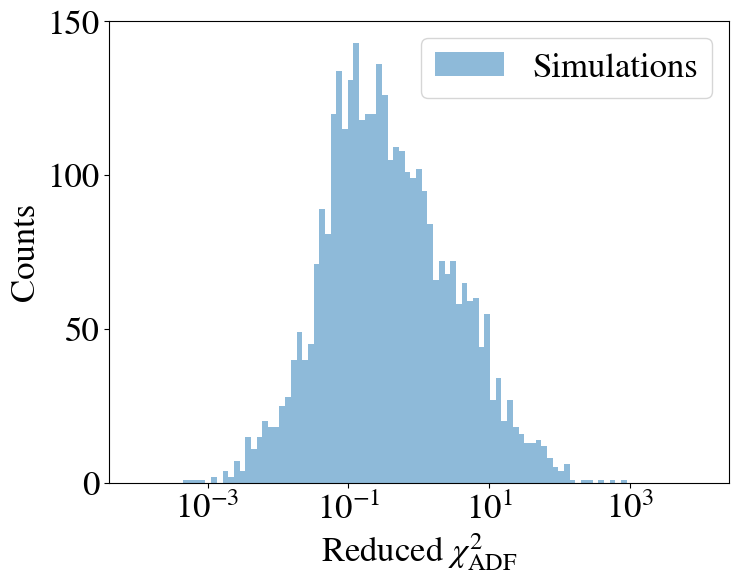

Fraction of events with reduced chi2 < 1000 :  1.0


In [7]:
logbins = np.logspace(-4, 4, 100)

plt.figure(figsize=(8,6))
plot_loghist(chi2_sims[~np.isnan(chi2_sims)], 
             bins=logbins, 
             alpha=0.5, 
             label='Simulations', 
            #  density=True
             )
plt.xlabel(r'Reduced $\chi^2_{\rm ADF}$')
plt.ylabel('Counts')
# plt.title('Distribution of Reduced chi2 for Simulations')
plt.legend()
plt.show()

print("Fraction of events with reduced chi2 < 1000 : ", len(chi2_sims[chi2_sims<1000])/len(chi2_sims))

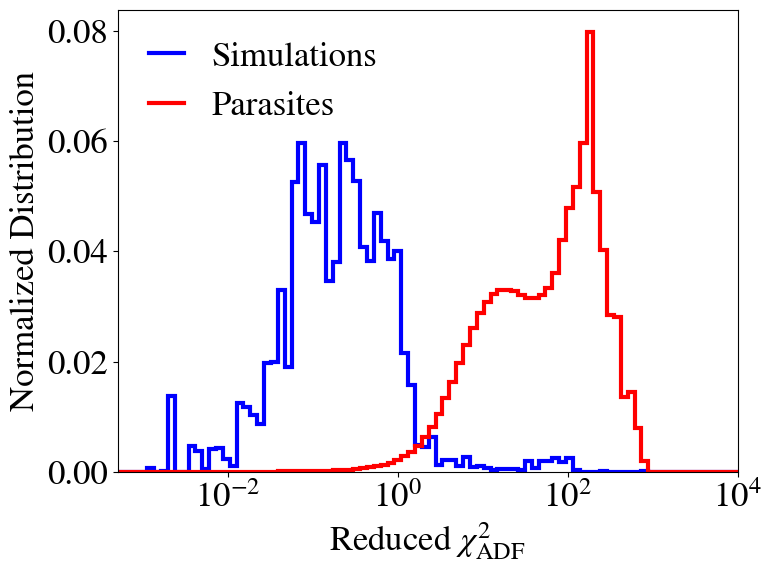

In [19]:

fig = plt.figure(figsize=(8, 6))

hist_chi2_sims, _ = np.histogram(chi2_sims, 
                                 bins=logbins,
                                 weights=weights_events
                                 )
norm_hist_chi2_sims = hist_chi2_sims / np.sum(weights_events)

plt.stairs(norm_hist_chi2_sims, 
           logbins, 
           label='Simulations', 
        #    alpha=0.5, 
           color='blue',
           linewidth=3,
           )

hist_chi2_parasites, _ = np.histogram(parasites_ADF_chi2, 
                                        bins=logbins
                                        )
norm_hist_chi2_parasites = hist_chi2_parasites / len(parasites_ADF_chi2)


plt.stairs(norm_hist_chi2_parasites, 
           logbins, 
           label='Parasites', 
        #    alpha=0.5, 
           color='red',
           linewidth=3,
           )


plt.xlabel(r'Reduced $\chi^2_{\rm ADF}$')
plt.ylabel('Normalized Distribution')
plt.xlim(5e-4, 1e4)
# plt.title('Distribution of Reduced chi2 for Simulations')
plt.xscale('log')
plt.legend(loc="upper left",
           frameon=False,
           handlelength=1
           )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/ADF_distrib_tot.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()


Cut efficiency for loss rate < 1% = 53.67% :  54.62
Threshold for loss rate = 0.95% :  54.62


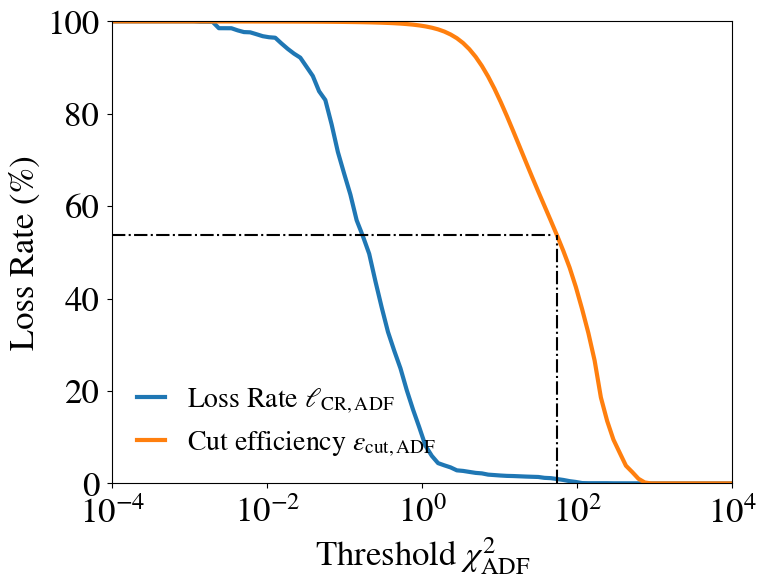

Threshold for loss rate = 0.95% :  54.62


In [20]:
# evaluate loss rate for different thresholds of reduced chi2
from matplotlib.ticker import MultipleLocator


chi2_thresholds = np.logspace(-4, 4, 100)


loss_rate = np.array([np.sum(weights_events[chi2_sims>chi2_thresholds[i]])/np.sum(weights_events) for i in range(len(chi2_thresholds))])
cut_efficency = 1 -np.array([len(parasites_ADF_chi2[parasites_ADF_chi2<chi2_thresholds[i]])/len(parasites_ADF_chi2) for i in range(len(chi2_thresholds))])


plt.figure(figsize=(8,6))
plt.plot(chi2_thresholds, 
             loss_rate*100, 
             linewidth=3, 
             label=r'Loss Rate $\ell_{\rm CR, ADF}$'
             )

plt.plot(chi2_thresholds, 
         100*cut_efficency, 
         label=r"Cut efficiency $\epsilon_{\rm cut, ADF}$",
            linewidth=3
         )

index_first_99 = np.where(loss_rate < 0.01)[0][0]
plt.plot(chi2_thresholds[index_first_99]+np.zeros(50),
         np.linspace(0, 100*cut_efficency[index_first_99], 50),
         color='black',
         linestyle='-.',
        #  label=r"$\epsilon_{\rm cut, ADF}$ for $\ell_{\rm CR, ADF}$ < 1%"
         )
plt.plot(chi2_thresholds[:index_first_99],
         100*cut_efficency[index_first_99]+np.zeros(len(chi2_thresholds[:index_first_99])),
         linestyle='-.',
         color='black',
        #  label=r"Cut eff for $\ell$ < 1%: {:.2f}%".format(100*cut_efficency[index_first_99])
         )

# plt.annotate(r"$\ell < 1\%$",
#              xy=(0.8, 0.9),
#              xytext=(2.5, 13),
#              fontsize=23
#              )
print(f"Cut efficiency for loss rate < 1% = {100*cut_efficency[index_first_99]:.2f}% :  {chi2_thresholds[index_first_99]:.2f}")
print(f"Threshold for loss rate = {loss_rate[index_first_99]*100:.2f}% :  {chi2_thresholds[index_first_99]:.2f}")
# plt.annotate(
#              r"$\epsilon_{\rm cut, ADF}=$" + f"{100*cut_efficency[index_first_99]:.2f}%",
#             #  f"{100*cut_efficency[index_first_99]:.2f}%",
#              xy=(0.8, 0.9),
#              xytext=(2.3e-4, 45),
#              fontsize=23
#              )

plt.xlabel(r'Threshold $\chi^2_{\rm ADF}$')
plt.xscale('log')
plt.ylabel('Loss Rate (%)')
plt.xlim(chi2_thresholds[0], chi2_thresholds[-1])
plt.ylim(0, 100)

# ax = plt.gca()
# ax.yaxis.set_minor_locator(MultipleLocator(5))

plt.tick_params(axis="both",
                which="both",
                # direction="in",
                pad=6
                )

plt.legend(fontsize=20,
           loc="lower left",
           frameon=False,
           handlelength=1
           )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/ADF_loss_cuteff_tot.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

print(f"Threshold for loss rate = {loss_rate[index_first_99]*100:.2f}% :  {chi2_thresholds[index_first_99]:.2f}")

## ADF vs SWF

In [10]:
parasites_chi2_SWF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_SWF_parasites.npy",
                    allow_pickle=True
                    ).item()

parasites_SWF_chi2 = np.array([])

for run in ADF_RUNs:
    parasites_SWF_chi2 = np.concatenate((parasites_SWF_chi2, parasites_chi2_SWF_RUN[run]))


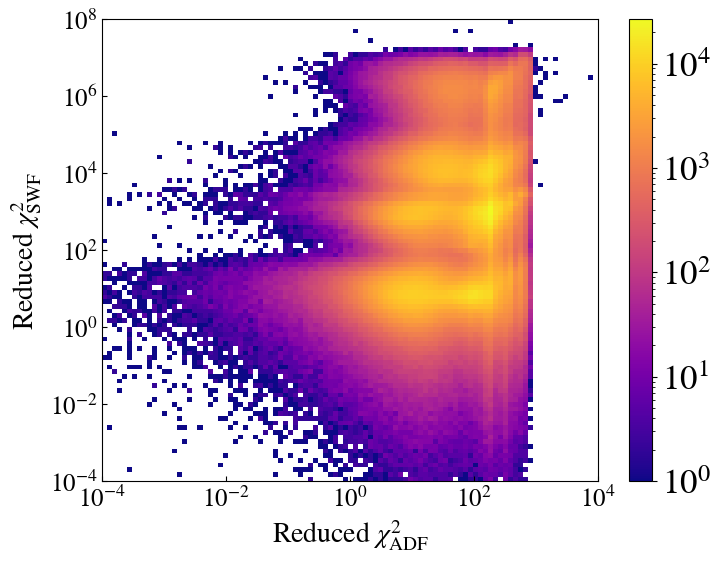

In [11]:
fig = plt.figure(figsize=(8,6))

plt.hist2d(parasites_ADF_chi2,
           parasites_SWF_chi2,
           bins=[np.logspace(-4, 4, 100),
                 np.logspace(-4, 8, 100)],
           norm=mpl.colors.LogNorm(),
           cmap='plasma'
           )

plt.colorbar()

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Reduced $\chi^2_{\rm ADF}$',
           fontsize=20
           )
plt.ylabel(r'Reduced $\chi^2_{\rm SWF}$',
           fontsize=20
           )
plt.tick_params(axis="both",
                direction="in",
                labelsize=18
                )

# add on the sides the distributions

## Efficiency in 2 dimensions

In [12]:
energy_zenith_hist2d = np.histogram2d(energy, 
                                      theta_true, 
                                      bins=(bins_energy, bins_theta), 
                                      )[0]
# no need for weighting here, since this histogram is used for efficiency, so each bin will be divided by itself

energy_zenith_after_SWFcut_hist2d = np.histogram2d(energy[chi2_sims < 1000],
                                                  theta_true[chi2_sims < 1000],
                                                  bins=(bins_energy, bins_theta),
                                                  )[0]

efficiency_energy_zenith = energy_zenith_after_SWFcut_hist2d / energy_zenith_hist2d


NameError: name 'bins_energy' is not defined

In [ ]:
# Measuring the total efficiency folded with expecting flux for each bin

folding_eff = np.load("/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_folded_events.npy")[0]

norm = np.sum(folding_eff[np.logical_not( np.isnan(efficiency_energy_zenith) )])

eff_total = np.sum(np.nan_to_num(efficiency_energy_zenith * folding_eff)) / norm
print("Total efficiency of the SWF reconstruction folded with expecting flux : ", eff_total)

Total efficiency of the SWF reconstruction folded with expecting flux :  0.8416255210493507


/scratch/users/j/jlavoisier/ipykernel_1466768/4196597165.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Flux-weighted efficiency : {:.2f}'.format(eff_total),


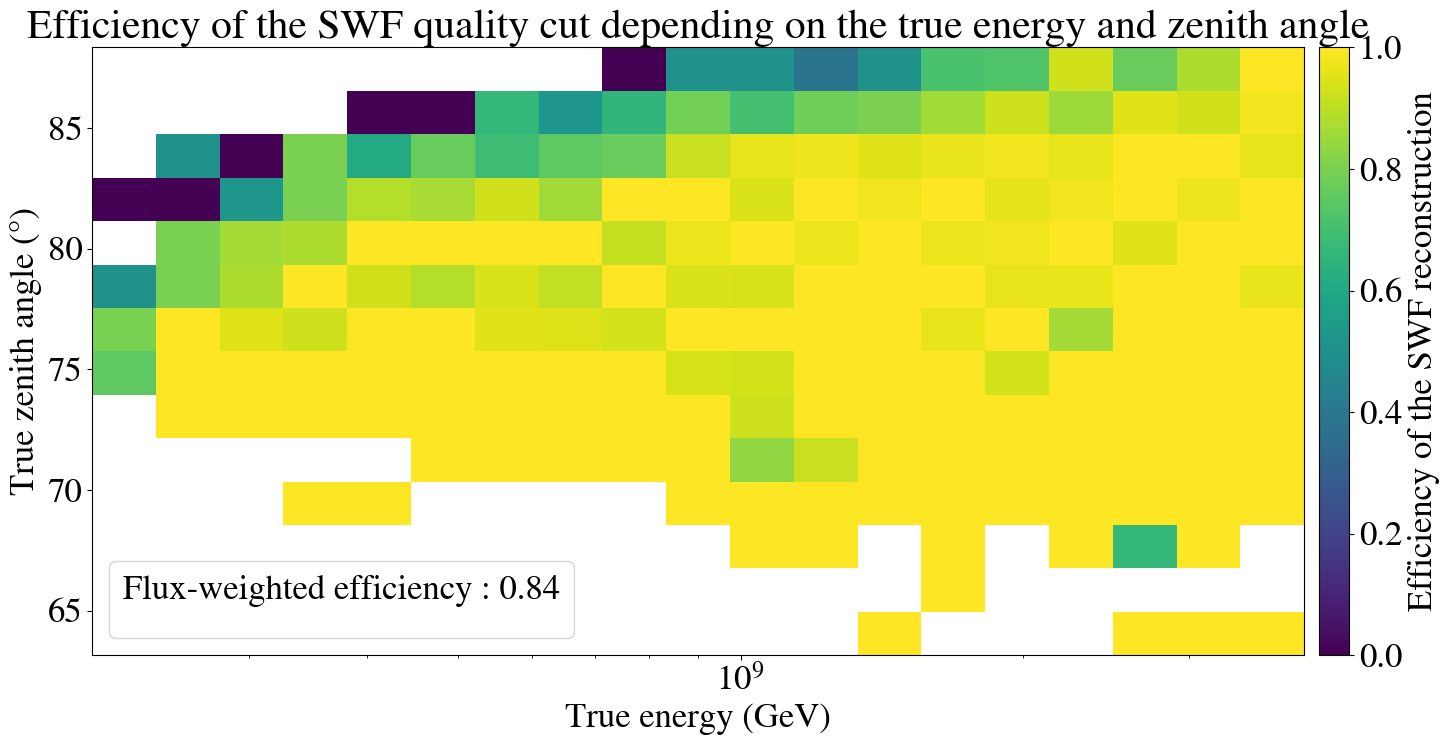

In [ ]:
X, Y = np.meshgrid(bins_energy, bins_theta)
im = plt.pcolormesh(X, 
                Y, 
                efficiency_energy_zenith.T, 
                cmap="viridis",
                # norm=mpl.colors.LogNorm(vmin=folded_events.min(), vmax=folded_events.max())
                )
plt.colorbar(im, label='Efficiency of the SWF reconstruction',
             pad=0.01)
plt.xlabel('True energy (GeV)')
plt.ylabel('True zenith angle (°)')
plt.title('Efficiency of the SWF quality cut depending on the true energy and zenith angle',
          wrap=True
          )
plt.legend(title='Flux-weighted efficiency : {:.2f}'.format(eff_total),
           loc='lower left'
           )
plt.xscale('log')
plt.tight_layout()
plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/SWF_quant/plots/efficiency_SWF_true_energy_zenith.png")
plt.show()